In [35]:
import pandas as pd 

In [36]:
# Đọc dữ liệu
true_data = pd.read_csv('News _dataset/True.csv')  # Tin thật
fake_data = pd.read_csv('News _dataset/Fake.csv')  # Tin giả

In [37]:
# Thêm cột nhãn
true_data['label'] = 1  # 1: Tin thật
fake_data['label'] = 0  # 0: Tin giả

In [38]:
data = pd.concat([true_data, fake_data], axis=0).reset_index(drop=True)

In [39]:
print(data.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       1  
1  December 29, 2017       1  
2  December 31, 2017       1  
3  December 30, 2017       1  
4  December 29, 2017       1  


In [40]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [41]:
lemmatizer = WordNetLemmatizer()

In [42]:
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # Loại bỏ dấu câu
    text = re.sub(r'\d+', '', text)      # Loại bỏ số
    text = text.lower()                  # Chuyển về chữ thường
    words = word_tokenize(text)          # Tokenize
    words = [word for word in words if word not in stop_words]  # Loại bỏ stop words
    words = [lemmatizer.lemmatize(word) for word in words]  # Lematize các từ
    return words

In [43]:
data['processed_text'] = data['text'].apply(preprocess_text)  # Giả sử cột chứa văn bản là 'text'

In [44]:
preprocess_text('The quick brown fox jumps over the lazy dog')

['quick', 'brown', 'fox', 'jump', 'lazy', 'dog']

In [45]:
from gensim.models import Word2Vec

In [46]:
sentences = data['processed_text'].tolist()
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

In [47]:
import numpy as np

In [48]:
embedding_dim = 100  # Kích thước vector Word2Vec
max_len = 50
# Tạo embedding matrix
def create_embedding_matrix(sentence, model, max_len):
    vectors = [model.wv[word] if word in model.wv else np.zeros(embedding_dim) for word in sentence]
    if len(vectors) < max_len:
        vectors += [np.zeros(embedding_dim)] * (max_len - len(vectors))  # Padding
    return np.array(vectors[:max_len])

In [49]:
data['embedding_matrix'] = data['processed_text'].apply(lambda x: create_embedding_matrix(x, word2vec_model, max_len))

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X = np.stack(data['embedding_matrix'].values)
y = data['label'].values

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout

In [54]:
max_len = 300  # Số từ tối đa trong mỗi bài báo
embedding_dim = 100  # Kích thước vector Word2Vec
model = Sequential([
    Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(max_len, embedding_dim)),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer='l2'),  # Thêm regularization
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [56]:
history = model.fit(
    X_train, y_train, 
    batch_size=32, 
    epochs=5,  # Giảm số lượng epoch
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.8816 - loss: 0.9737 - val_accuracy: 0.9976 - val_loss: 0.1221
Epoch 2/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9960 - loss: 0.0919 - val_accuracy: 0.9976 - val_loss: 0.0286
Epoch 3/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9968 - loss: 0.0294 - val_accuracy: 0.9978 - val_loss: 0.0250
Epoch 4/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9971 - loss: 0.0239 - val_accuracy: 0.9977 - val_loss: 0.0222
Epoch 5/5
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9973 - loss: 0.0221 - val_accuracy: 0.9978 - val_loss: 0.0264


In [57]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9976 - loss: 0.0233
Accuracy: 99.78%


In [58]:
def check_fake_news(text, model, word2vec_model, max_len):
    # Tiền xử lý văn bản
    processed_text = preprocess_text(text)

    # Chuyển thành embedding matrix
    embedding = create_embedding_matrix(processed_text, word2vec_model, max_len)
    embedding = np.expand_dims(embedding, axis=0)  # Thêm chiều batch

    # Dự đoán
    prediction = model.predict(embedding)
    return "Fake News" if prediction[0][0] < 0.5 else "True News"

In [59]:
new_text = "WASHINGTON (Reuters) - The final version of comprehensive tax legislation being negotiated by House and Senate lawmakers will preserve key renewable energy tax credits that were once at risk of being removed, congressional and business sources said on Thursday. Congressional Republicans reached a deal on tax legislation on Wednesday, clearing the way for final votes next week on a package that would slash the U.S. corporate tax rate to 21 percent and cut taxes for wealthy Americans. Congressional and business sources briefed on the status of these talks have confirmed that the production tax credit for wind energy and the $7,500 electric vehicle tax credit, which the House version of the bill had targeted, will remain in the final bill. Lawmakers have been working to produce a tax package after the Republican-controlled House and Senate passed different versions of legislation.  The president of the American Council on Renewable Energy, Gregory Wetstone, sent a note to members on Wednesday saying that he knew â€œwith certaintyâ€ that the legislation also did not include the alternative minimum tax (AMT) for corporations that would have reduced the value of the production tax credit (PTC) for wind projects. Meanwhile, the renewable energy industry is awaiting final details on how congressional negotiators will address problems created by a provision included in the Senate-passed bill called the Base Erosion Anti-Abuse Tax (BEAT). This measure was intended to prevent multinational companies from abusing the tax code but would make tax credits like the PTC for wind less valuable. This provision would have chilled investment by international companies like Vestas, and banks in the renewable energy sector, industry experts said. Wetstone said negotiators are working on a fix that would allow the PTC to offset at least 80 percent of the BEAT tax imposed on multinational companies. Another source briefed on the negotiations said that as much as 90 percent of credits could be used to offset the BEAT tax. â€œWe are still unclear about the precise terms of deal, but itâ€™s good news for the whole sector,â€ said Liam Donovan, a lobbyist with Bracewell focused on tax, infrastructure and energy."
result = check_fake_news(new_text, model, word2vec_model, max_len)
print(f"Đoạn văn bản là: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Đoạn văn bản là: True News


In [60]:
import joblib
joblib.dump(model, 'CNN_model_using_Word2Vec.pkl')

['CNN_model_using_Word2Vec.pkl']

In [61]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# Dự đoán nhãn của tập kiểm tra
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()  # Chuyển kết quả dự đoán thành nhãn 0 hoặc 1

# Tính toán các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


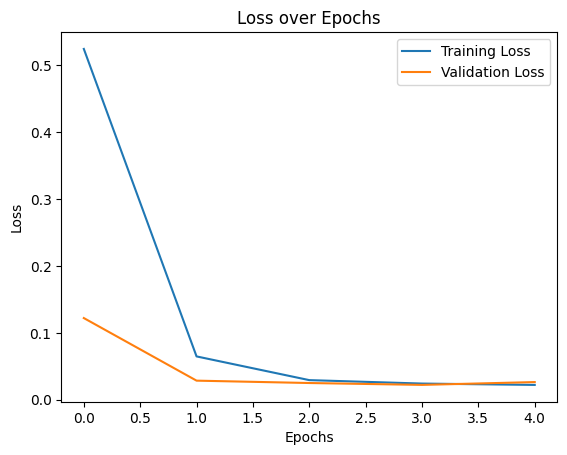

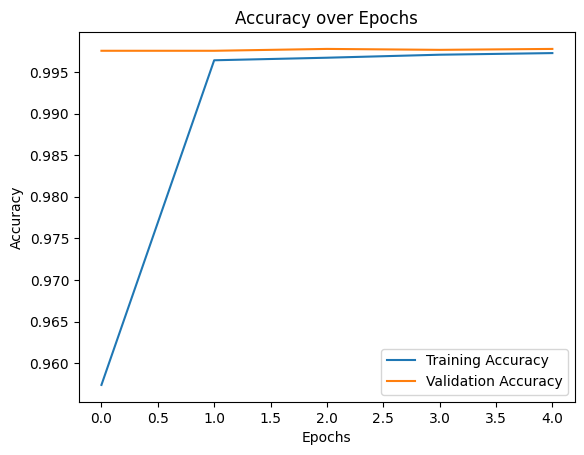

In [62]:
import matplotlib.pyplot as plt
# Vẽ biểu đồ Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Vẽ biểu đồ Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [69]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# ===== 1. Đọc và cân bằng dữ liệu =====
true_data = pd.read_csv('News _dataset/True.csv')
fake_data = pd.read_csv('News _dataset/Fake.csv')

# Lấy mẫu cân bằng
min_samples = min(len(true_data), len(fake_data))
true_data = true_data.sample(min_samples, random_state=42)
fake_data = fake_data.sample(min_samples, random_state=42)

# Thêm nhãn
true_data['label'] = 1
fake_data['label'] = 0
data = pd.concat([true_data, fake_data], axis=0).reset_index(drop=True)

# ===== 2. Tiền xử lý =====
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # Loại bỏ dấu câu
    text = re.sub(r'\d+', '', text)     # Loại bỏ số
    text = text.lower()                 # Chuyển về chữ thường
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]  # Loại bỏ stopwords
    words = [lemmatizer.lemmatize(word) for word in words]      # Lemmatize
    return words

data['processed_text'] = data['text'].apply(preprocess_text)

# ===== 3. Word2Vec và Embedding =====
embedding_dim = 100
max_len = 50

sentences = data['processed_text'].tolist()
word2vec_model = Word2Vec(sentences, vector_size=embedding_dim, window=5, min_count=1, workers=4)

def create_embedding_matrix(sentence, model, max_len):
    vectors = [model.wv[word] if word in model.wv else np.zeros(embedding_dim) for word in sentence]
    if len(vectors) < max_len:
        vectors += [np.zeros(embedding_dim)] * (max_len - len(vectors))  # Padding
    return np.array(vectors[:max_len])

data['embedding_matrix'] = data['processed_text'].apply(lambda x: create_embedding_matrix(x, word2vec_model, max_len))

# ===== 4. Tách dữ liệu =====
X = np.stack(data['embedding_matrix'].values)
y = data['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ===== 5. Xây dựng mô hình CNN =====
model = Sequential([
    Conv1D(filters=128, kernel_size=5, activation='relu', 
           input_shape=(max_len, embedding_dim), kernel_regularizer=l2(0.01)),
    GlobalMaxPooling1D(),
    Dropout(0.6),  # Tăng Dropout để tránh overfitting
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ===== 6. Thêm EarlyStopping =====
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    batch_size=16,  # Giảm batch size
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

# ===== 7. Đánh giá mô hình =====
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - accuracy: 0.8842 - loss: 1.5604 - val_accuracy: 0.9985 - val_loss: 0.0933
Epoch 2/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9955 - loss: 0.0905 - val_accuracy: 0.9985 - val_loss: 0.0522
Epoch 3/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9950 - loss: 0.0778 - val_accuracy: 0.9985 - val_loss: 0.0369
Epoch 4/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9944 - loss: 0.0704 - val_accuracy: 0.9985 - val_loss: 0.0494
Epoch 5/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9947 - loss: 0.0708 - val_accuracy: 0.9985 - val_loss: 0.0329
Epoch 6/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9949 - loss: 0.0622 - val_accuracy: 0.9985 - val_loss: 0.0402
Epoch 7/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9940 - loss: 0.0641 - val_accuracy: 0.9985 - val_loss: 0.0355
Epoch 8/20
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9951 - loss: 0

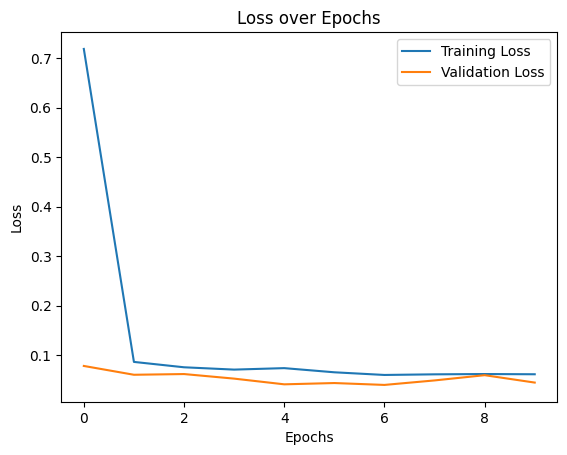

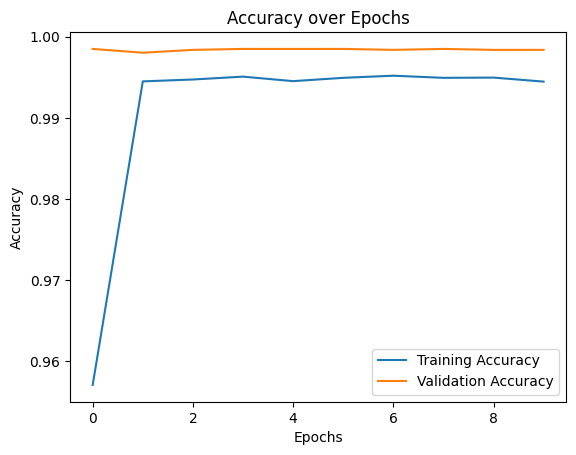

In [66]:
import matplotlib.pyplot as plt
# Vẽ biểu đồ Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Vẽ biểu đồ Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [67]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# Dự đoán nhãn của tập kiểm tra
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()  # Chuyển kết quả dự đoán thành nhãn 0 hoặc 1

# Tính toán các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4284
           1       1.00      1.00      1.00      4283

    accuracy                           1.00      8567
   macro avg       1.00      1.00      1.00      8567
weighted avg       1.00      1.00      1.00      8567

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


In [6]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Đọc dữ liệu
true_data = pd.read_csv('News _dataset/True.csv')
fake_data = pd.read_csv('News _dataset/Fake.csv')

# Thêm nhãn
true_data['label'] = 1  # Tin thật
fake_data['label'] = 0  # Tin giả

# Gộp dữ liệu
data = pd.concat([true_data, fake_data], ignore_index=True)
texts = data['text']
labels = data['label']

# 2. Tiền xử lý văn bản
def preprocess_text(text):
    text = re.sub(r'\W', ' ', text)  # Loại bỏ ký tự đặc biệt
    text = re.sub(r'\s+', ' ', text)  # Loại bỏ khoảng trắng thừa
    text = text.lower()  # Chuyển thành chữ thường
    return text

data['text'] = texts.apply(preprocess_text)

# 3. Tạo nhúng Word2Vec
sentences = [text.split() for text in data['text']]
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# Chuyển từ sang số bằng tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['text'])
sequences = tokenizer.texts_to_sequences(data['text'])

# Padding chuỗi
max_len = 200
X = pad_sequences(sequences, maxlen=max_len)
y = labels.values

# Tạo ma trận nhúng
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

# 4. Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# Xây dựng mô hình CNN
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, weights=[embedding_matrix], input_length=max_len, trainable=False),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Phân loại nhị phân
])

# Biên dịch mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test, y_test))
# Đánh giá mô hình
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))


c:\Users\Admin\OneDrive\Tài liệu\Fake_news_detection_project\venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.8837 - loss: 0.3107 - val_accuracy: 0.9751 - val_loss: 0.0688
Epoch 2/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.9765 - loss: 0.0689 - val_accuracy: 0.9790 - val_loss: 0.0608
Epoch 3/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9869 - loss: 0.0398 - val_accuracy: 0.9841 - val_loss: 0.0479
Epoch 4/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - accuracy: 0.9890 - loss: 0.0315 - val_accuracy: 0.9856 - val_loss: 0.0442
Epoch 5/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.9944 - loss: 0.0187 - val_accuracy: 0.9857 - val_loss: 0.0518
Epoch 6/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9955 - loss: 0.0133 - val_accuracy: 0.9763 - val_loss: 0.0862
Epoch 7/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.9952 - loss: 0.0160 - val_accuracy: 0.9783 - val_loss: 0.0789
Epoch 8/10
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.9969 -

In [8]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# Dự đoán nhãn của tập kiểm tra
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()  # Chuyển kết quả dự đoán thành nhãn 0 hoặc 1

# Tính toán các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4650
           1       0.99      0.97      0.98      4330

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980

Accuracy: 0.98
Precision: 0.99
Recall: 0.97
F1 Score: 0.98


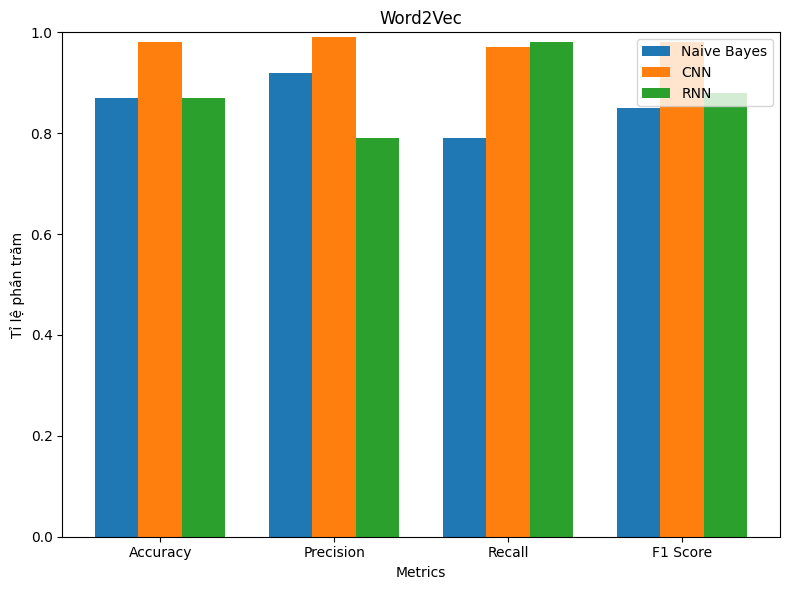

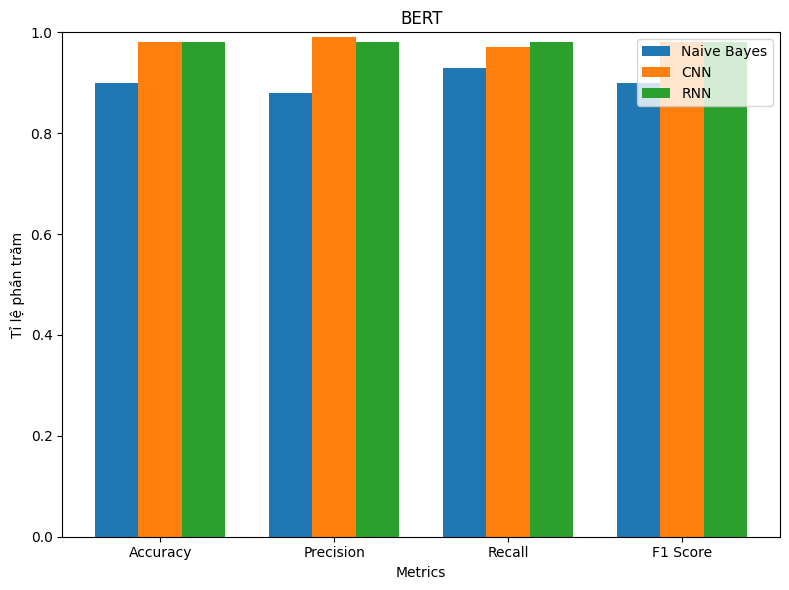

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu từ bảng
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models = ['Naive Bayes', 'CNN', 'RNN']

# Dữ liệu nhúng Word2Vec
word2vec_data = [
    [0.87, 0.92, 0.79, 0.85],  # Naive Bayes
    [0.98, 0.99, 0.97, 0.98],  # CNN
    [0.87, 0.79, 0.98, 0.88]   # RNN
]

# Dữ liệu nhúng BERT
bert_data = [
    [0.90, 0.88, 0.93, 0.90],  # Naive Bayes
    [0.98, 0.99, 0.97, 0.98],  # CNN
    [0.98, 0.98, 0.98, 0.98]   # RNN
]

# Chuyển đổi dữ liệu về dạng numpy
word2vec_data = np.array(word2vec_data).T  # Transpose để theo metrics
bert_data = np.array(bert_data).T          # Transpose để theo metrics

# Vẽ biểu đồ Word2Vec
plt.figure(figsize=(8, 6))
x = np.arange(len(metrics))  # Vị trí các metrics
width = 0.25  # Độ rộng cột

for i, model in enumerate(models):
    plt.bar(x + i * width, word2vec_data[:, i], width, label=model)

plt.title('Word2Vec')
plt.xticks(x + width, metrics)
plt.ylim(0, 1.0)  # Giới hạn Y-axis từ 70% đến 100%
plt.ylabel('Tỉ lệ phần trăm')
plt.xlabel('Metrics')
plt.legend()

# Lưu biểu đồ Word2Vec
plt.tight_layout()
plt.savefig("word2vec_chart.png")
plt.show()

# Vẽ biểu đồ BERT
plt.figure(figsize=(8, 6))
for i, model in enumerate(models):
    plt.bar(x + i * width, bert_data[:, i], width, label=model)

plt.title('BERT')
plt.xticks(x + width, metrics)
plt.ylim(0, 1.0)
plt.ylabel('Tỉ lệ phần trăm')
plt.xlabel('Metrics')
plt.legend()

# Lưu biểu đồ BERT
plt.tight_layout()
plt.savefig("bert_chart.png")
plt.show()
